In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from IPython.display import display, Markdown

mpl.rcParams['font.size'] = 16

In [2]:
def read_file(filename):
    with open(filename) as f:
        data = []
        for line in f:
            line =  line.rstrip().lstrip()
            if not line:
                continue

            temp = line.split()
            data.append(float(temp[4]))

    return data

def plot_hist(data):
    fig = plt.figure(figsize=(10, 5))
    ax1 = fig.add_subplot(111)
    ax1.hist(data, bins=range(0, int(np.max(data))))
    ax1.set_xlabel('time [ms]')
    ax1.set_xlim(0, 10)
    ax1.set_ylabel('Queries #')

    #fig.savefig(f'{output}-hist.png', dpi=300)
    plt.show()

def plots(filename, title):
    data = read_file(filename)
    output=f'''
## {title}
**Total time**: {np.sum(data):.3f} ms

**Average time**: {np.mean(data):.3f} ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | {np.percentile(data, 99):.3f} |
| 90  | {np.percentile(data, 90):.3f} |
| 75  | {np.percentile(data, 75):.3f} |
| 50  | {np.percentile(data, 50):.3f} |
| 25  | {np.percentile(data, 25):.3f} |
    '''
    display(Markdown(output))
    plot_hist(data)


## Machine Native Optimization
**Total time**: 39296.625 ms

**Average time**: 1.740 ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | 6.325 |
| 90  | 3.505 |
| 75  | 2.657 |
| 50  | 1.372 |
| 25  | 0.502 |
    

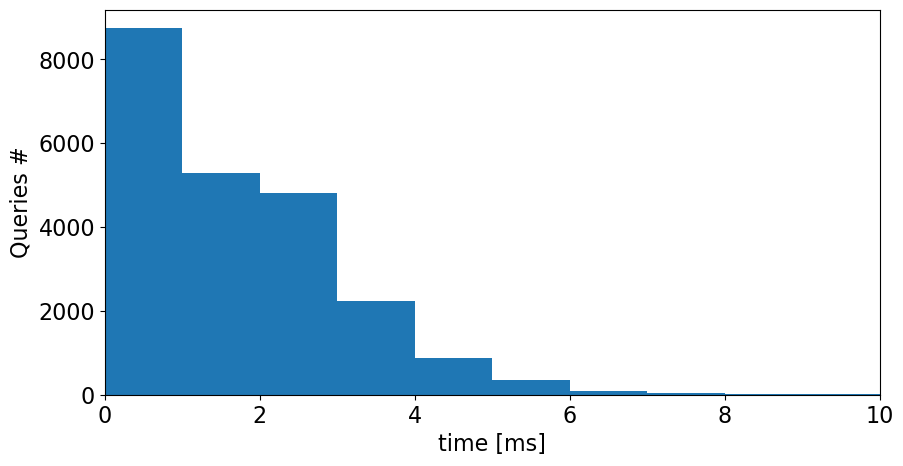

In [3]:
plots('machine-native.log', 'Machine Native Optimization')


## AVX512VPOPCNTDQ Optimization
**Total time**: 26174.145 ms

**Average time**: 1.159 ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | 4.060 |
| 90  | 2.699 |
| 75  | 1.924 |
| 50  | 0.768 |
| 25  | 0.272 |
    

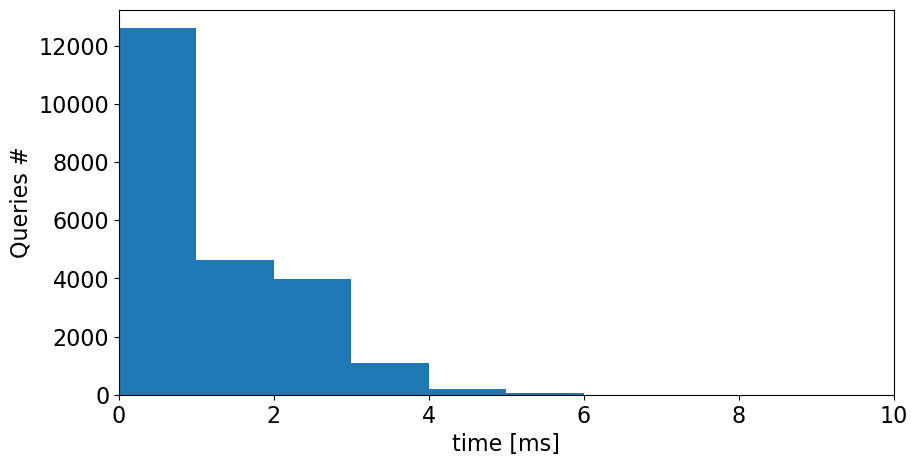

In [4]:
plots('avx512.log', 'AVX512VPOPCNTDQ Optimization')


## Default SSE-4.2 Optimization
**Total time**: 41930.587 ms

**Average time**: 1.857 ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | 7.298 |
| 90  | 4.492 |
| 75  | 3.113 |
| 50  | 1.059 |
| 25  | 0.324 |
    

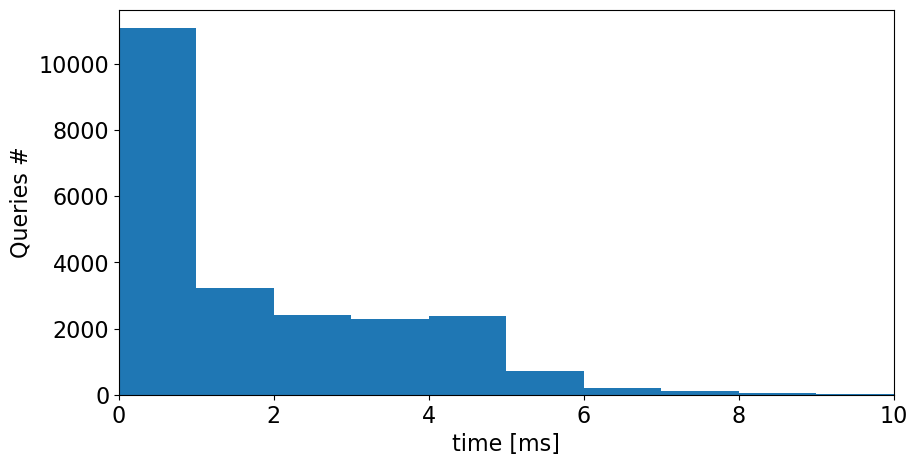

In [5]:
plots('sse42.log', 'Default SSE-4.2 Optimization')

In [6]:
batch_serial_data = []
with open('./batch-vs-sequential.log') as f:
    for line in f:
        line =  line.rstrip().lstrip()
        if not line:
            continue

        temp = line.split()
        batch_serial_data.append(list(map(float, temp)))

In [7]:
speedups = {}
for d in batch_serial_data:
    if int(d[1]) not in speedups:
        speedups[int(d[1])] = [ d[4] ]
    else:
        speedups[int(d[1])].append(d[4])

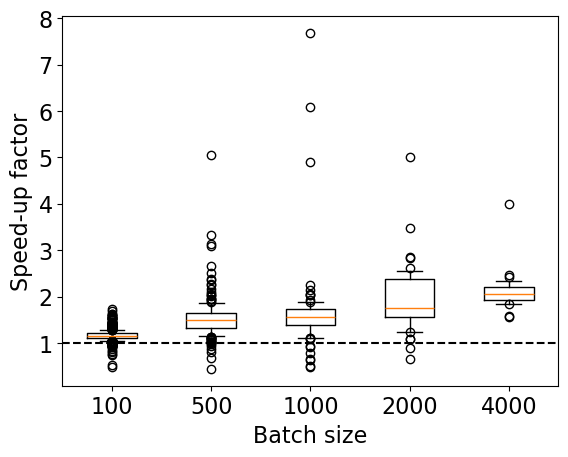

In [8]:
xticks = range(1, len(speedups) + 1)
plt.plot([0.5, 5.5], [1, 1], '--', c='k')
plt.boxplot(list(speedups.values()), whis=(10,90))
plt.xticks(xticks, list(speedups.keys()))
plt.xlabel('Batch size')
plt.ylabel('Speed-up factor') 
plt.show()